# Pipeline completo de Processamento de Linguagem Natural

# 1. Introdução

**KDD** (*Knowledge Discovery in Databases*) é um processo interativo e iterativo para a identificação de padrões válidos, novos, potencialmente úteis e entendíveis de dados ([Fayyad et al. 1996](https://ojs.aaai.org/aimagazine/index.php/aimagazine/article/view/1230)). É composto por 5 fases:

1. **Seleção**: escolha de um conjunto ou subconjunto de variáveis e amostras de "dados-alvo" na qual a descoberta será performada.
2. **Pré-processamento**: aumento da qualidade dos dados por meio de remoção de ruídos e manipulação de dados ausentes.
3. **Transformação**: armazenamento e formatação dos dados em que a ferramenta de mineração será aplicada.
4. **Mineração de Dados**: exploração de padrões e regras de interesse em um forma de representação específica.
5. **Interpretação e Avaliação**: extração e visualização dos padrões e regras gerados, além da validação de sua capacidade de aprendizado.

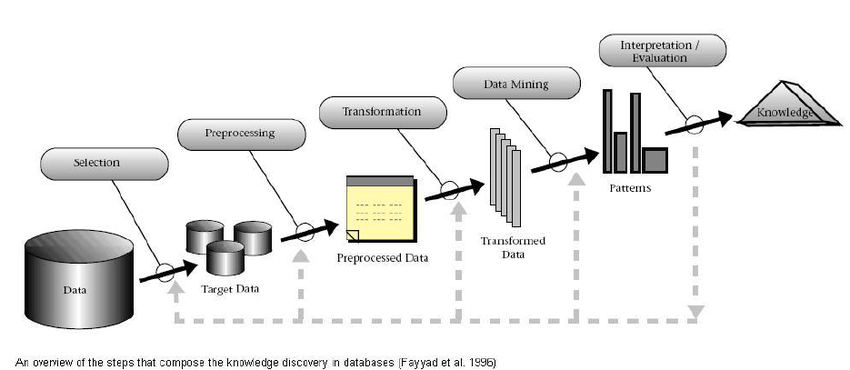


Vamos utilizar o KDD e suas etapas para guiar o minicurso.

# 2. Configurações iniciais

O ambiente de desenvolvimento utilizado é conhecido como Jupyter, um caderno de notas (notebooks) executado em navegadores que é útil para desenvolvimento, colaboração, compartilhamento e publicação de projetos de ciência e mineração de dados.

Os notebooks são compostos por células de pelo menos dois tipos: célula de código-fonte, onde é possível fazer a execução de scripts na linguagem Python (apesar de existirem notebooks para outras linguagens), e Markdown, uma linguagem de marcação que possibilita a estilização de texto plano, disponibilizando assim um ambiente organizado, explicativo e replicável.

O ambiente Jupyter pode ser encontrado e executado de duas formas:
- Local: utiliza os recursos computacionais da máquina do usuário, necessitando de instalação e configuração através de gerenciadores de pacotes, como Pip ou Conda.
- Nuvem: utiliza os recursos computacionais disponibilizados por um serviço dedicado, sem necessidade de instalação e configuração, sendo os mais conhecidos o Google Colab, Kaggle Kernels, Noteable, Azure Notebooks, e muito mais.

O Google Colab é um ambiente baseado em notebooks do Jupyter executado em nuvem, e será usado para a execução proposta neste documento. As células de código abaixo possuem o símbolo `[]`, além de possuírem numeração de linha. Para executá-las, posicione o cursor do mouse sobre `[]` e pressione o botão de *play* `▶` que irá aparecer no lugar. Uma alternativa para essa execução é selecionar a célula e usar `Ctrl+Enter`.

## 2.1. Importação dos pacotes

Aqui serão importados os pacotes de processamentos de dados da linguagem Python que vamos utilizar ao longo da execução. Lembre-se de que estes já estão instalados no ambiente padrão do Google Colab, e portanto não precisam de instalação. São eles:

- `statistics`: pacote nativo que inclui diversas funções para cálculos estatísticos em cima de dados fornecidos pelo usuário.
- `numpy`: pacote de análise numérica de dados.
- `pandas`: pacote de manipulação de dados tabulares.
- `nltk`: processamento de linguagem natural tradicional.
- `spacy`: processamento de linguagem natural avançado.
- `plotly`: pacote de visualização da informação que cria gráficos interativos e dinâmicos.
- `sklearn`: pacote que inclui diversas classes e funções clássicas para rotinas de aprendizado de máquina.
- `tensorflow`: pacote de aprendizado profundo de máquina.
- `keras`: pacote que proporciona uma interface simplificada e amigável ao tensorflow.

In [ ]:
import statistics

import numpy as np
import pandas as pd

import nltk
from nltk.stem import RSLPStemmer
from nltk.tokenize import word_tokenize

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SpatialDropout1D,
    LSTM,
    Dense,
    Flatten
)

## 2.3. Download dos dados

A base de dados utilizada na presente análise é a [*AG Corpus of News*](http://groups.di.unipi.it/~gulli/AG_corpus_of_news_articles.html), uma coleção de mais de 1 milhão de notícias reunidas usando mais de 2000 fontes durante quase 1 ano de atividade. O dataset aqui presente é uma seleção do [*AG News Classification Dataset*](https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset), que é específico para classificação de texto. Possui 4 classes de notícias (*World*, *Sports*, *Business* e *Science*), 127600 amostras e atributos de títulos e descrições.

Vamos utilizar o pacote GDown instalado anteriormente para baixar o dataset armazenado no Google Drive.

In [ ]:
!gdown 1re8vKnlXzXUOBXxDMzEJhpaF35rZ9zoC

Ao terminar o download, verifique no painel lateral esquerdo o menu `📁` "Arquivos" ou "Files". O arquivo `data.psv` deve estar presente no diretório de trabalho atual.

# 3. Processo KDD

A seguir, vamos explorar a base de dados a fim de gerar um modelo que concentre o conhecimento extraído que seja necessário para a execução da tarefa de classificação de um texto de notícias internacionais em até 4 classes. O processo KDD ajuda a organizar esse processo e a garantir um mínimo de procedimentos imprescendíveis para a exploração de qualquer tarefa de extração de conhecimento. Dessa forma, vamos utilizar suas 5 etapas e descrever suas respectivas subtarefas.

## 3.1. Seleção

A seleção trata da escolha do conjunto de dados alvo e escolha de subconjuntos de variáveis ou amostras na qual a descoberta de conhecimento será performada. Abordaremos aqui somente a subtarefa de carregamento dos dados.

O método `read_csv` do Pandas faz o carregamento de arquivos do tipo *Comma Separated Values* e retorna um objeto do tipo DataFrame, uma tabela que armazena e refencia os dados do arquivo por meio de suas colunas e índices. Os DataFrames são utilizados ao longo da manipulação de dados por conterem diversos atributos e métodos que facilitam este processo.

Vamos armazenar o DataFrame na variável `df`, utilizando o método `read_csv` passando dois parâmetros:

- `filepath_or_buffer`: o caminho para o arquivo csv a ser carregado.
- `sep`: o caractere de separação das colunas. Vamos utilizar o caractere pipe | pela sua eficiência em separar dados textuais.

In [ ]:
# carregamento dos dados

df = pd.read_csv(
    filepath_or_buffer="data.psv",
    sep="|"
)

df

Ao longo do pré-processamento, vamos utilizar o DataFrame armazenado em `df`, que vai sofrer as devidas alterações até assumir um formato aceitável de ser passado para o algoritmo de aprendizado. A quantidade de linhas e colunas do DataFrame é expressa respectivamente por:

In [ ]:
df.shape

Outra informação importante de ser destacada são os tipos de dados das colunas, dado por:

In [ ]:
df.dtypes

### 3.1.1. Title

Antes de passar para as etapas do KDD que efetivamente alteram os dados carregados, vamos analisar as colunas no seu formato original.

A primeira coluna é a de título (*Title*). O script a seguir realiza a extração do comprimento dos títulos da notícia em termos da quantidade de caracteres e plota um gráfico de violino, onde podemos observar a distribuição desses comprimentos, as medidas de tendência central e possíveis valores discrepantes. A largura da curva do violino expressa a quantidade de amostras expressas para o valor analisado.

In [ ]:
# gráfico violino do comprimento dos títulos

title_length = df["title"].str.len()

fig_title = px.violin(
    title_length,
    box=True,
    title="Comprimento dos títulos",
    width=800,
    height=600
)

fig_title.show()

### 3.1.2. Description

Da mesma forma, o script a seguir gera o gráfico de violino para a coluna de descrições (*description*).

In [ ]:
# gráfico violino do comprimento das descrições

description_length = df["description"].str.len()

fig_description = px.violin(
    description_length,
    box=True,
    title="Comprimento das descrições",
    width=800,
    height=600
)

fig_description.show()

### 3.1.3. Class

Por fim, podemos analisar a coluna de classe (class), mas não em termos de distribuição numérica de comprimentos, e sim em relação a quantidade de amostras por classes únicas. O script a seguir realiza essa contagem e gera um gráfico de barras correspondente.

In [ ]:
# gráfico de barras da quantidade de amostras por classe

class_counts = df["class"].value_counts()

fig_class = px.bar(
    class_counts,
    text_auto=".2s",
    title="Quantidade de amostras por classe",
    width=800,
    height=600
)

fig_class.show()

## 3.2. Pré-processamento

O pré-processamento trata da remoção de ruído e manipulação de dados ausentes e discrepantes. Aqui serão abordadas as tarefas de remoção de dados duplicados, remoção de dados ausentes, e remoção de dados extremos.

### 3.2.1. Dados duplicados

Dados duplicados podem acontecer ao longo de colunas, linhas e combinações destes.

Os títulos duplicados são listados a seguir, utilizando o método `duplicated`:

In [ ]:
# títulos duplicados

df.loc[df["title"].duplicated()]

Da mesma forma, as descrições duplicadas também são listadas:

In [ ]:
# descrições duplicadas

df.loc[df["description"].duplicated()]

Por fim, dados duplicados são eliminados com o método `drop_duplicated`.

In [ ]:
# eliminação de duplicatas

df = df.drop_duplicates(subset="title")
df = df.drop_duplicates(subset="description")
df

### 3.2.2. Dados ausentes

Dados ausentes podem ser listados com o método `isna`. No conjunto de dados apresentado não existem dados ausentes:

In [ ]:
# amostras com títulos ausentes

df.loc[df["title"].isna()]

In [ ]:
# amostras com descrições ausentes

df.loc[df["description"].isna()]

In [ ]:
# amostras com classes ausentes

df.loc[df["class"].isna()]

### 3.2.3. Dados extremos (outliers)

Outliers (ou dados extremos) são amostras de dados que alteram o comportamento esperado do conjunto de dados, seja por erro de medição ou registro ou mesmo pela presença de eventos raros.

A detecção de outliers é uma tarefa que depende diretamente dos tipos de dados a serem analisados. Para dados textuais, um importante indicativo de outliers são os comprimentos dos textos, que foram extraídos em novas colunas por meio do seguinte script:

In [ ]:
# extração da quantidade de caracteres nos títulos e descrições

df["len_title"] = df["title"].str.len()
df["len_description"] = df["description"].str.len()
df

De posse do comprimento de cada texto, precisamos definir uma função que determine se um texto qualquer é ou não um outlier. Existem diversas condicionais de verificação de outliers, mas vamos aferir aqui que um valor é outlier caso seja excedente da diferença de um quartil (pontos onde se concentram 25%, 50% e 75%) e o triplo de sua amplitude interquartil (diferença entre os limites dos quartis de 75% e 25%).

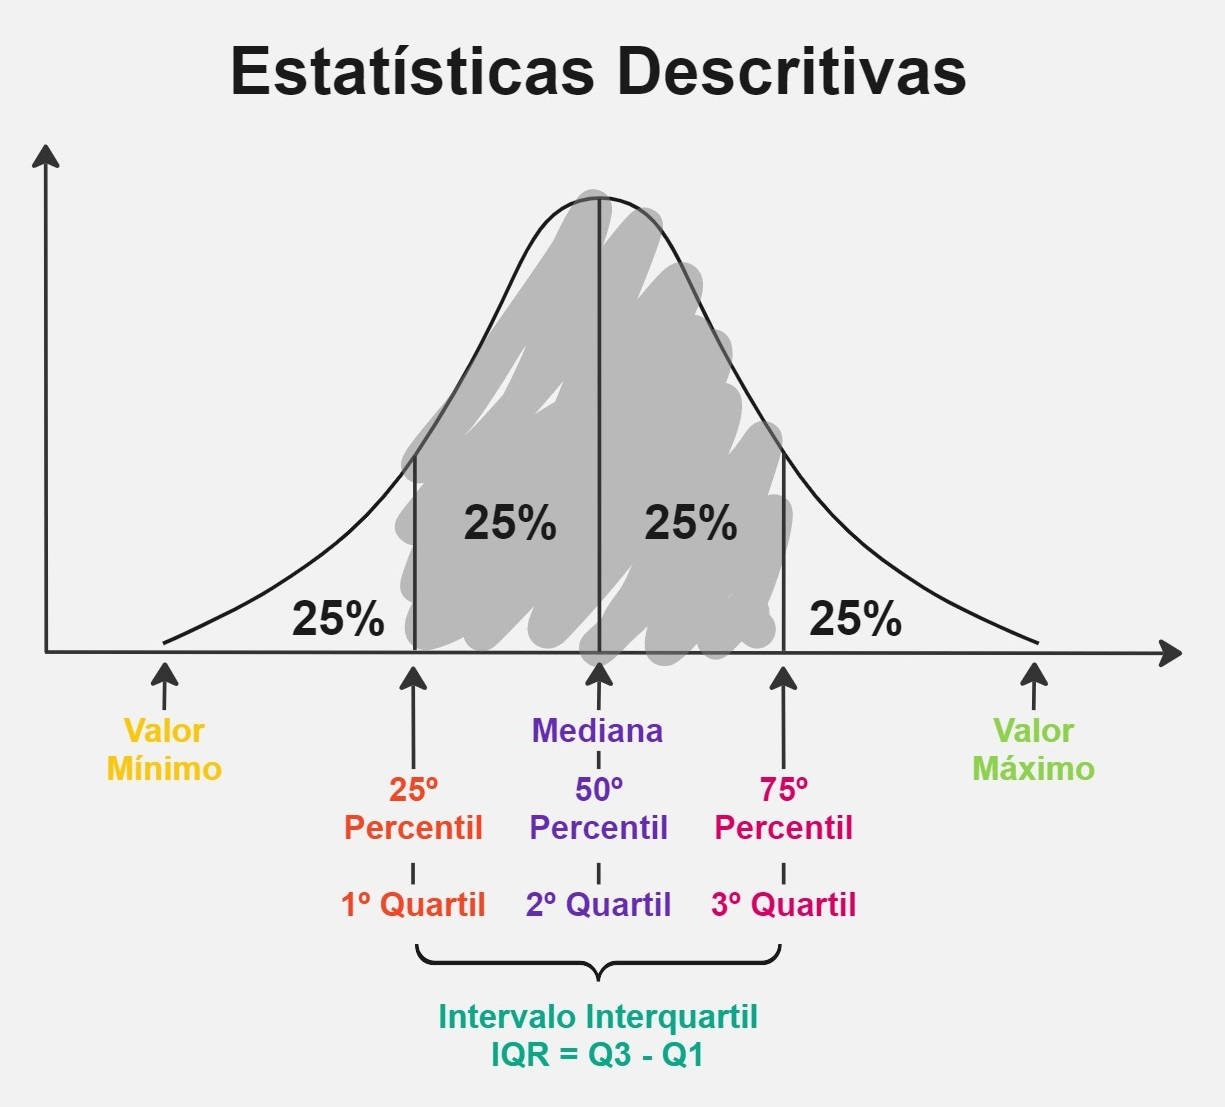

In [ ]:
# função para determinar se um valor é outlier

def check_outlier(value, quantiles, amplitude):
    if (value < quantiles[0] - (3 * amplitude)) or (value > quantiles[2] + (3 * amplitude)):
        return True
    return False

A seguir são listados os quartis e a amplitude interquartil para a distribuição de comprimentos dos títulos, além da execução da função de determinação de outliers.

In [ ]:
# quartis das quantidades de caracteres dos títulos

quantiles_title = statistics.quantiles(df["len_title"])
print("Quartis de title:", quantiles_title)

# amplitude interquartil das quantidades de caracteres dos títulos

amplitude_title = quantiles_title[2] - quantiles_title[0]
print("Amplitude interquartil de title:", amplitude_title)

# determinação dos outliers nos títulos

df["outlier_title"] = df["len_title"].map(lambda x: check_outlier(
    value=x,
    quantiles=quantiles_title,
    amplitude=amplitude_title
))

De forma análoga, os quartis, a amplitude interquartil e a execução da função de determinação de outliers são executados para as descrições.

In [ ]:
# quartis das quantidades de caracteres das descrições

quantiles_description = statistics.quantiles(df["len_description"])
print("Quartis de description:", quantiles_description)

# amplitude interquartil das quantidades de caracteres das descrições

amplitude_description = quantiles_description[2] - quantiles_description[0]
print("Amplitude interquartil de description:", amplitude_description)

# determinação dos outliers nas descrições

df["outlier_description"] = df["len_description"].map(lambda x: check_outlier(
    value=x,
    quantiles=quantiles_description,
    amplitude=amplitude_description
))

Podemos listar quais amostras possuem outliers no título ou na descrição.

In [ ]:
# amostras que são outliers nos títulos ou descrições

df.loc[(df["outlier_title"]) | (df["outlier_description"])]

E finalmente fazemos a eliminação dos outliers, filtrando as colunas do DataFrame para manter as colunas originais.

In [ ]:
# eliminação das amostras que são outliers nos títulos ou descrições

df = df.loc[~((df["outlier_title"]) | (df["outlier_description"]))]
df = df[["title", "description", "class"]]
df

Ao executar o mesmo script de geração do gráfico de violino da etapa de seleção, podemos acompanhar a mudança na distribuição de comprimentos de títulos.

In [ ]:
# gráfico violino do comprimento dos títulos após o pré-processamento

title_length_post = df["title"].str.len()

fig_length_post = px.violin(
    title_length_post,
    box=True,
    title="Comprimento dos títulos (após pré-processamento)",
    width=800,
    height=600
)

fig_length_post.show()

Da mesma maneira, podemos visualizar a nova distribuição de comprimentos das descrições.

In [ ]:
# gráfico violino do comprimento das descrições após o pré-processamento

description_length_post = df["description"].str.len()

fig_length_post = px.violin(
    description_length_post,
    box=True,
    title="Comprimento das descrições (após pré-processamento)",
    width=800,
    height=600
)

fig_length_post.show()

Apesar da melhoria nas distribuições anteriores, a eliminação de outliers traz um problema na distribuição de classes únicas: o desbalanceamento das classes. Este problema será resolvido na etapa de transformação.

In [ ]:
# gráfico de barras da quantidade de amostras por classe após o pré-processamento

class_counts = df["class"].value_counts()

fig_class_post = px.bar(
    class_counts,
    text_auto=".2s",
    title="Quantidade de amostras por classe (após pré-processamento)",
    width=800,
    height=600
)

fig_class_post.show()

## 3.3. Transformação

A transformação trata do destaque dos atributos que melhor representam os dados para a tarefa de descoberta de conhecimento, através de redução de dimensionalidade ou formatação dos dados para entrada em algoritmos de processamento. As subtarefas exploradas aqui são a união dos textos, normalização das capitalizações, o balanceamento das classes e a transformação dos atributos textuais em números.

### 3.3.1. Unir texto

A fim de simplificar o processamento de texto, vamos unir as colunas textuais em uma única coluna chamada `text`. Dessa forma, cada amostra assume o formato "*title: description*".

In [ ]:
# unindo cada título e descrição em um único texto

df["text"] = df["title"] + ": " + df["description"]
df = df[["text", "class"]]
df

### 3.3.2. Normalizar capitalização

Note que a capitalização aumenta consideravelmente a variabilidade de palavras. "*News*", "*news*" e "*NEWS*" possuem de um mesmo significado mas para o computador se tratam de palavras diferentes pois têm capitalizações diferentes, por exemplo.

Assim, é importante normalizar a capitalização, transformado todos os caracteres para minúsculo ou maiúsculo. Neste sentido, vamos normalizar o texto para minúsculo.

In [ ]:
# tornar todas as letras do texto minúsculas

df["text"] = df["text"].str.lower()
df

### 3.3.3. Remoção de stopwords

Vamos remover as palavras de parada que não trazem relevância semântica para o texto. Para isso, podemos carregar as stopwords listadas na biblioteca NLTK para a língua inglesa.

In [ ]:
nltk.download('stopwords')

In [ ]:
stopwords = nltk.corpus.stopwords.words("english")
stopwords = set(stopwords)
stopwords

Em seguida, usamos o método `apply()` do Pandas para aplicar uma função que liste apenas as palavras que não são stopwords, para cada exemplo da base de dados.

In [ ]:
df["text"] = df["text"].apply(lambda x: " ".join([word for word in x.split() if word not in stopwords]))
df

### 3.3.4. Stemming

O stemming transforma cada token em sua forma radical, eliminando sufixos que possam variar a forma da palavra. Para implementá-la, vamos utilizar a biblioteca NLTK para criar uma função que tokenize e transforme os tokens para seu lemma.

In [ ]:
stemmer = RSLPStemmer()

def stemming(stemmer, texto):
    tokens = word_tokenize(str(texto), language="portuguese")
    stems = [stemmer.stem(token) for token in tokens]
    return ' '.join(stems)

Novamente, aplicamos a função a todo o corpo de texto.

In [ ]:
df["text"] = df["text"].map(lambda x: stemming(stemmer, str(x)))
df

### 3.3.5. Balancear quantidade de classes

Como resultado da remoção de outliers, a quantidade de classes únicas no DataFrame atual está desbalanceada. A contagem destas classes é dada por:

In [ ]:
# contagem de valores únicos de classes

class_count = df["class"].value_counts()
class_count

Observe a quantidade de amostras da classe com menos amostras:

In [ ]:
MIN_CLASS_COUNT = class_count.min()
MIN_CLASS_COUNT

Para balancear as classes podemos seguir duas estratégias:
1. Eliminar algumas amostras de classes que possuem quantitativo maior que a classe com o menor quantitativo, de forma a garantir a maior quantidade possível de amostras.
2. Definir um número de amostras menor que esse quantitativo mínimo, eliminando algumas amostras de todas as classes até alcançar este valor.

As próximas instruções requerem que o usuário forneça um quantitativo da quantidade de amostras que vamos utilizar para cada classe. Se esse número seja menor que a quantidade de amostras mínima mencionada acima, usaremos a estratégia 2. Caso seja superior a esse valor ou sequer seja fornecida, vamos utilizar a estratégia 1.

In [ ]:
try:
    NUM_SAMPLES = int(input("Insira a quantidade de amostras por classe: "))
except ValueError:
    NUM_SAMPLES = MIN_CLASS_COUNT

NUM_SAMPLES

De posse dessa quantidade, vamos selecionar aleatoriamente uma quantidade de amostras para cada classe, além de embaralhar o dataset.

In [ ]:
# reduzindo a quantidade de amostras por classe de forma balanceada

samples_by_class = [df.loc[df["class"] == label].sample(NUM_SAMPLES) for label in df["class"].unique()]
df = pd.concat(samples_by_class)
df = df.sample(frac=1)
df = df.reset_index(drop=True)
df

Dessa forma, o dataset está novamente balanceado.

In [ ]:
# nova contagem de valores únicos de classes

df["class"].value_counts()

### 3.3.6. Transformar texto para números

Neste ponto, o DataFrame está pronto para ser transformado em um formato que seja aceito pelo algoritmo de aprendizado. Essa transformação consiste na vetorização dos textos em números, onde vamos utilizar a técnica de tokenização e sequenciamento para os textos descritivos e de *One-Hot Encoding* para as classes.

O *tokenizer* é um objeto que realiza a quebra do texto em palavras únicas ao longo de toda a coluna textual, sendo uma espécie de dicionário léxico do domínio do problema apresentado. Sua criação possui os seguintes argumentos:

- `num_words`: a quantidade máxima de palavras a serem extraídas.
- `filters`: caracteres que não devem ser considerados, geralmente incluindo sinais de pontuação.
- `lower`: transformação dos caracteres para minúsculo.
- `split`: caractere de quebra das palabras, geralmente é o espaço simples.
- `char_level`: determinar se a quebra será a nível de caractere ou palavra.

Depois da criação do *tokenizer*, usamos o método fit_on_texts para efetivamente extrair as palavras dos textos.

In [ ]:
# criação e ajuste do tokenizer

tokenizer = Tokenizer(
    num_words=100000,
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True,
    split=' ',
    char_level=False,
)

tokenizer.fit_on_texts(df["text"])

Agora podemos analizar as contagens de palavras únicas contidas no *tokenizer*. O DataFrame `df_word_counts` é um ranking das palavras mais frequentes no conjunto de dados.

In [ ]:
# ranking das palavras encontradas no conjunto de dados

df_word_counts = pd.DataFrame(tokenizer.word_counts.items())
df_word_counts.columns = ["word", "count"]
df_word_counts = df_word_counts.sort_values(by="count", ascending=False)
df_word_counts = df_word_counts.reset_index(drop=True)
df_word_counts

O script a seguir gera um gráfico de barras das *n* palavras mais frequentes.

In [ ]:
# gráfico de barras das palavras mais frequentes no conjunto de dados

try:
    n = int(input("Insira a quantidade de palavras frequentes da visualização: "))
except ValueError:
    n = 50

fig = px.bar(
    df_word_counts.iloc[:n, :],
    x="word",
    y="count",
    title=f"As {n} palavras mais frequentes no conjunto de dados",
    width=1200,
    height=600,
    labels={
        "count": "Contagem",
        "word": "Palavras"
    }
)

fig.show()

A transformação de textos em números requer a criação de um vetor $m \times n$, onde $m$ é a quantidade de amostras e $n$ é uma quantidade fixa de palavras por amostra. Para este último, insira a quantidade de palavras a ser mantida em cada sequência de texto.

In [ ]:
try:
    MAX_LEN = int(input("Insira a quantidade palavras em cada sequência de texto: "))
except ValueError:
    MAX_LEN = 64

MAX_LEN

De posse dessa quantidade, podemos aplicar os seguintes métodos:

- `texts_to_sequences`: criação das sequências de números baseado no ranking de palavras do tokenizer.
- `pad_sequences`: ajuste da quantidade máxima de palavras em cada sequência. Caso a sequência seja menor que o limite, adicione 0s antes da sequência. Caso a sequência seja maior, remova as últimas palavras da sequência.

Assim, obtemos o vetor `X`, utilizado diretamente na etapa de mineração de dados.

In [ ]:
# transformação de textos em sequências de números

sequences = tokenizer.texts_to_sequences(df["text"].values)

X = pad_sequences(
    sequences=sequences,
    maxlen=MAX_LEN,
    padding="pre",
    truncating="post",
)

X

Observe o formato de X.

In [ ]:
# formato de X

X.shape

### 3.3.7. Transformar classes para números

Também precisamos transformar as classes em números, mas tratando estas como se fossem categorias. Primeiro extraímos as classes únicas, ordenamos alfabeticamente os resultados e armazenamos isso na variável `label`.

In [ ]:
# extrair e ordenar classes únicas

unique_classes = df["class"].unique()
labels = sorted(unique_classes)
labels

Em seguida, transformamos essas classes em tipos categóricos de dados e realizamos a aplicação da técnica One-Hot Encoding, que gera um vetor binário em que cada posição do eixo horizontal corresponde a uma classe, e cada 1 associado a uma linha representa a classe daquela linha. Para entender esse mapeamento observe o vetor resultante `y`.

In [ ]:
# transformar categorias em números (One-Hot Encoding)

category_type = pd.CategoricalDtype(categories=labels)
classes_as_categories = df["class"].astype(category_type)
dummies = pd.get_dummies(classes_as_categories)
y = dummies.values
y

Observe também o formato de `y`.

In [ ]:
# shape of y

y.shape

Por fim, observe que a posição onde se encontra o único 1 de cada linha corresponde à classe originial.

In [ ]:
# mapeamento das classes em números

df_class_mappings = pd.concat([df["class"], pd.DataFrame(y)], axis=1)
df_class_mappings

De posse de `X` e `y`, finalmente podemos iniciar a mineração de dados.

## 3.4. Mineração de dados

A mineração de dados trata da aplicação de representações formais e modelos de representação de dados na procura por padrões de interesse nos dados processados. As subtarefas associadas são a divisão dos conjuntos de treino e teste, a criação do modelo e o treinamento do modelo.

### 3.4.3. Divisão de treino e teste

A partir de X e y, precisamos criar dois subconjuntos para cada um:

- Treino: configura os dados que serão passados para o treinamento do modelo de aprendizado.
- Test: configura os dados que serão passados para o teste e avaliação do modelo de aprendizado.

A divisão precisa agir sobre um percentual da quantidade de amostras totais. Portanto, informe um valor entre 0 e 1 para extrair a quantidade dos dados de teste, que será complementado pela quantidade de dados de treinamento.

In [ ]:
# tamanho do conjunto de teste

try:
    TEST_SIZE = int(input("Insira a proporção dos subconjuntos de teste (0 < x < 1): "))
except ValueError:
    TEST_SIZE = 0.33

TEST_SIZE

As amostras dos conjuntos de treino e teste não podem ter interseção, pois não faz sentido testar sobre o que já foi aprendido. Para garantir isso vamos usar o método `train_test_split`, que gera os quatro subconjuntos de interesse.

In [ ]:
# divisão treino-teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=42
)

O DataFrame `df_shapes` resume os formatos dos quatro subconjuntos de dados que vamos trabalhar.

In [ ]:
# shapes dos 4 subconjuntos resultantes

df_shapes = pd.DataFrame({
    "X": [X_train.shape, X_test.shape],
    "Y": [y_train.shape, y_test.shape]
})
df_shapes.index = ["train", "test"]
df_shapes

### 3.4.4. Criação do modelo

O modelo de aprendizado que vamos usar é baseado em Redes Neurais Recorrentes dot tipo LSTM (Long-Short Term Memory). Vamos configurar os parâmetros dessa rede a seguir:

In [ ]:
# parâmetros de configuração do modelo

try:
    VOCAB_LENGTH = int(input("Insira o tamanho do vocabulário (10000 < x < 500000): "))
except ValueError:
    VOCAB_LENGTH = 100000

try:
    EMBEDDING_DIM = int(input("Insira a dimensão de embedding (10 < x < 100): "))
except ValueError:
    EMBEDDING_DIM = 64

try:
    INPUT_LENGTH = int(input("Insira o tamanho da entrada da rede (10 < x < 500): "))
except ValueError:
    INPUT_LENGTH = 256

try:
    DROP_RATE = int(input("Insira a proporção de entradas a serem resetadas (0 < x < 1): "))
except ValueError:
    DROP_RATE = 0.2

try:
    RECURRENT_DROPOUT = int(input("Insira a proporção de entradas a serem resetadas na recorrência (0 < x < 1): "))
except ValueError:
    RECURRENT_DROPOUT = 0.2

VOCAB_LENGTH, EMBEDDING_DIM, INPUT_LENGTH, DROP_RATE, RECURRENT_DROPOUT

Além desses, temos parâmetros fixos que recomendamos não alterar.

In [ ]:
# parâmetros fixos (não alterar!)

ACTIVATION = "softmax"
LOSS = "categorical_crossentropy"
OPTIMIZER = "adam"
METRICS = ["accuracy"]

Em seguida fazemos a configuração das camadas da rede neural, utilizando o conceito da *Functional API* do Keras. Nela, uma única variável `x` armazena a topologia das camadas agregadas desde a entrada até a saída da rede.

In [ ]:
# camadas da rede neural

_input: Input = Input(shape=(X_train.shape[1],))

embedding: Embedding = Embedding(
    input_dim=VOCAB_LENGTH,
    output_dim=EMBEDDING_DIM,
    input_length=INPUT_LENGTH
)

x = embedding(_input)

x = SpatialDropout1D(rate=DROP_RATE)(x)

x = LSTM(EMBEDDING_DIM, dropout=DROP_RATE, recurrent_dropout=RECURRENT_DROPOUT)(x)

x = Dense(len(labels), activation=ACTIVATION)(x)

output = Flatten()(x)

Concluindo a criação do modelo, passamos suas variáveis de entrada e saída para o construtor `Model` e compilamos esta rede usando o restante dos parâmetros fixos.

In [ ]:
# criação e compilação do modelo

model = Model(_input, output)

model.compile(
    loss=LOSS,
    optimizer=OPTIMIZER,
    metrics=METRICS
)

A seguir, apresentamos o resumo da arquitetura da rede criada.

In [ ]:
# resumo da rede neural criada

model.summary()

Para efeitos de visualização, as camadas estão distribuídas da seguinte forma.

In [ ]:
plot_model(
    model,
    show_shapes=True,
    show_dtype=True,
    show_layer_names=False,
    rankdir="LR",
    show_layer_activations=True,
)

### 3.4.6. Treinamento do modelo

O treinamento do modelo necessita de pelo menos dois parâmetros:

- `epochs`: a quantidade de vezes que o conjunto de treinamento será apresentado ao modelo. Tem efeito direto na exploração do espaço de busca da solução do problema.
- `batch_size`: o tamanho de amostras apresentada a cada atualização da exploração.

In [ ]:
# parâmetros de configuração do treinamento

try:
    EPOCHS = int(input("Insira a quantidade de épocas (1 < x < 10): "))
except ValueError:
    EPOCHS = 10

try:
    BATCH_SIZE = int(input("Insira o tamanho do batch (10 < x < 1000): "))
except ValueError:
    BATCH_SIZE = 512

EPOCHS, BATCH_SIZE

Finalmente é iniciado o processo de treinamento, cujo histórico é armazenado em `history`. Note que o tempo de execução deste processo depende de diversas variáveis configuradas anteriormente, incluindo a quantidade de amostras por classe, a quantidade de palavras por sequência, o tamanho do conjunto de treinamento e o número de épocas.

In [ ]:
# treinamento do modelo

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Ao finalizar o treinamento, execute o seguinte script para visualização do seu histórico.

In [ ]:
# gráficos de linhas do histórico de treinamento

fig_history = make_subplots(rows=2, cols=1)

fig_history.add_trace(
    go.Scatter(
        x=[str(i) for i in range(1, EPOCHS + 1)],
        y=history.history["loss"],
        name="Perda"
    ),
    row=1, col=1
)

fig_history.add_trace(
    go.Scatter(
        x=[str(i) for i in range(1, EPOCHS + 1)],
        y=history.history["accuracy"],
        name="Acurácia",
    ),
    row=2, col=1
)

fig_history.update_xaxes(title_text="Época", row=1, col=1)
fig_history.update_xaxes(title_text="Época", row=2, col=1)
fig_history.update_yaxes(title_text="Perda", row=1, col=1)
fig_history.update_yaxes(title_text="Acurácia", row=2, col=1)

fig_history.update_layout(
    width=600, height=600,
    title_text="Evolução do Treinamento",
)

fig_history.show()

Ao final da etapa de mineração, a variável `model` possui a arquitetura de rede neural e os pesos extraídos a partir do treinamento que representa o conhecimento necessário para executar a tarefa de classificação. Podemos então avaliar este modelo para verificação da qualidade do processo.

## 3.5. Avaliação

A avaliação trata da visualização dos padrões extraídos, dos dados gerados pelos
modelos de mineração, e possível retorno a qualquer uma das etapas anteriores. A predição e a extração da matriz de confusão e da acurária geral são as subtarefas associadas com essa validação.

### 3.5.1. Predição

A avaliação utiliza do subconjunto de teste para realizar predições em cima de dados que o modelo não entrou em contato durante o treinamento, a fim de verificar se o conhecimento extraído é generalizável, ou seja, é aplicável a novos cenários similares aqueles de onde foi originado.

O método `predict` realiza esse processamento, de onde vamos armazenar seu resultado na variável `y_pred`, um vetor de predições no formato $m \times n$, onde $m$ é quantidade de amostras de teste e $n$ é a quantidade de classes aprendidas. O vetor armazena a probabilidade entre 0 e 1 de ocorrência da classe para cada amostra.

In [ ]:
# predição sobre os dados de teste

y_pred = model.predict(
    x=X_test,
    batch_size=BATCH_SIZE,
    verbose=1
)

y_pred

As probabilidades de predição podem ser melhor visualizadas a partir do DataFrame `df_y_pred`, que destaca o valor de predição máxima e compara com a classe esperada para as 20 primeiras amostras de teste.

In [ ]:
# visualizando predições e comparando com o esperado

df_y_pred = pd.DataFrame(y_pred)
df_y_pred.columns = labels
df_y_pred["class"] = [labels[i] for i in y_test.argmax(axis=1)]
df_y_pred.head(20).style.highlight_max(color='green', subset=labels, axis=1)

Podemos testar não apenas os textos do subconjunto de teste, mas qualquer texto de notícia proposto. A função `classify_text` aplica a pipeline de processamento que construímos ao longo do documento para fazer a predição da classe de um texto qualquer.

In [ ]:
# função para classificação de um texto qualquer

def classify_text(text):
    text = text.lower()
    sequences = tokenizer.texts_to_sequences([text])
    X = pad_sequences(
        sequences=sequences,
        maxlen=MAX_LEN,
        padding="pre",
        truncating="pre",
    )
    y_pred = model.predict(X, verbose=0)
    return [labels[i] for i in y_pred.argmax(axis=1)][0]

Execute a instrução a seguir e teste outros textos de notícias para verificar as classificações do modelo construído.

In [ ]:
# classificação de um texto qualquer

my_text = "Real Madrid are the UEFA Champions League winners after a thrilling match against Borussia Dortmund"
classify_text(my_text)

### 3.5.2. Matriz de confusão

A matriz de confusão é uma das principais técnicas de avaliação de tarefas de classificação. Consiste em uma tabela onde são dispostos os quantitativos de classes esperados na horizontal e os quantitativos de classes preditas na vertical. Assim, não somente podemos contar a quantidade de amostras preditas com sucesso na diagonal principal, mas também analisar o que acontece com os casos de erro.

In [ ]:
# matriz de confusão

cm = confusion_matrix(
    y_true=y_test.argmax(axis=1),
    y_pred=y_pred.argmax(axis=1),
)

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
cm_display.plot()

### 3.5.3. Acurácia geral

De posse da matriz de confusão, podemos extrair a acurácia geral do modelo sobre o subconjunto de teste, por meio da razão entre a soma de amostras de sua diagonal principal (corretamente preditos) e a quantidade total de amostras.

In [ ]:
# acurácia geral

general_cm = pd.DataFrame(cm, index=labels, columns=labels)

ACCURACY = sum([general_cm.iloc[i, i] for i in range(len(general_cm))]) / general_cm.sum().sum()

ACCURACY

# 4. Resumo

Para concluir, segue um resumo da sua execução.

In [ ]:
# variáveis ajustadas na execução

summary = {
    "NUM_SAMPLES": [NUM_SAMPLES],
    "TEST_SIZE": [TEST_SIZE],
    "VOCAB_LENGTH": [VOCAB_LENGTH],
    "EMBEDDING_DIM": [EMBEDDING_DIM],
    "INPUT_LENGTH": [INPUT_LENGTH],
    "DROP_RATE": [DROP_RATE],
    "RECURRENT_DROPOUT": [RECURRENT_DROPOUT],
    "EPOCHS": [EPOCHS],
    "BATCH_SIZE": [BATCH_SIZE],
    "ACCURACY": [ACCURACY]
}

df_summary = pd.DataFrame(summary)
df_summary